# Melbourne Weather Code Workflow

## Data Cleaning

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# import numpy, pandas, scipy, statsmodels

# print(numpy.__version__)
# print(pandas.__version__)
# print(scipy.__version__)
# print(statsmodels.__version__)

In [3]:
melb = pd.read_csv("Melbourne01.csv",low_memory=False,on_bad_lines="skip")


In [4]:
melb.columns = ['Year', 'Month', 'Day', 'Hour', 'Min', 'Air Temp (degrees C)',
       'Apparent Temp (degrees C)', 'Dew Pt Temp (degrees C)', 'Humidity (%)',
       'Wind Direction', 'Wind Speed (km/h)', 'Wind Gust  (km/h)',
       'MSLP (hPa)', 'Rainfall since 9 am (mm)']

In [5]:
melb_str = melb[melb["Month"].map(type) == str]

melb["Year"].value_counts()

2015                                                                   120022
2016                                                                    93673
2020                                                                    93243
2017                                                                    93159
2019                                                                    93102
                                                                        ...  
2015\t05\t14\t22\t00\t12.8\t11.7\t12\t95\tSW\t19\t24\t1034.1\t0.6           1
2015\t05\t14\t22\t30\t12.5\t11.8\t11.9\t96\tWSW\t17\t24\t1034\t0.6          1
2015\t05\t14\t23\t00\t12.3\t11.8\t12\t98\tSW\t19\t24\t1034\t0.8             1
2015\t05\t14\t23\t30\t12.1\t11.3\t11.8\t98\tSW\t19\t22\t1034.1\t0.8         1
2017\t8\t30\t17\t00\t11.9\t8.4\t3.4\t50\tS\t22\t30\t1028.8\t0.2\t           1
Name: Year, Length: 631, dtype: int64

In [6]:
tabbed_months = melb_str["Month"].unique()[12:28]

In [7]:
melb = melb.astype("object")
n_position = 580364
for month in tabbed_months:
    month = month.split("\t")
    empty_first = [""] + month
    row = pd.Series(empty_first)
    try:
        row = pd.to_numeric(row)
    except ValueError:
        pass
    row= row.to_list()
    melb.loc[n_position] = row
    melb.iloc[n_position,0] = 2017
    n_position +=1


    # month = month.split("\t")

    # row = ["2017"] + month   # keep raw values first

    # melb.loc[n_position] = row  # insert raw row first

    # n_position += 1
# melb = melb.apply(pd.to_numeric, errors="coerce")
# rows = []

# for month in tabbed_months:
#     parts = month.split("\t")
#     row = ["2017"] + parts
#     rows.append(row)


# new_df = pd.DataFrame(rows)


# new_df.columns = melb.columns
# melb = pd.concat([melb, new_df], ignore_index=True)

# melb = melb.sort_values(by=["Year", "Month", "Day", "Hour", "Min"])
# melb = melb.reset_index(drop=True)

In [8]:
fix_year = melb[melb['Month'].isna()].loc[::,"Year"]
indices = melb[melb['Month'].isna()].index.to_list()

In [9]:
y_position = 0
for year in fix_year:
    year = year.strip()
    year = year.split("\t")
    # row = pd.to_numeric(pd.Series(year), errors = 'ignore').to_list()

    row = pd.Series(year)
    try:
        row = pd.to_numeric(row)
    except ValueError:
        pass
    row=row.to_list()
    
    y_ind = indices[y_position]
    melb.loc[y_ind] = row
    y_position +=1

In [10]:
melb["Year"].value_counts()

2015    120194
2016     93673
2020     93365
2017     93184
2018     93156
2014     93155
2019     93112
2013     90510
2011     89961
2012     88409
2022     66410
2021     53589
2024     21509
2023     17818
2025      5090
2017        16
Name: Year, dtype: int64

In [11]:
melb["Day"] = melb["Day"].astype(int, errors = 'ignore')

In [12]:
melb["Year"] = melb["Year"].astype(int)

In [13]:
replace_month = {' 1': 1,
                 ' 2': 2,
                 ' 3': 3,
                 ' 4': 4,
                 ' 5': 5,
                 ' 6': 6,
                 ' 7': 7,
                 ' 8': 8,
                 ' 9': 9,
                 ' 10': 10,
                 ' 11': 11,
                 ' 12': 12,
                 ' 06': 6,
                 ' 03': 3,
                 ' 04': 4,
                 ' 05': 5,
                 ' 07': 7,
                 ' 08': 8,
                 ' 09': 9,
                 ' 01': 1,
                 ' 02': 2,
                 '09': 9,
                 '05': 5,
                 '02': 2,
                 '08': 8,
                 '1': 1,
                 '6': 6,
                 '8': 8,
                 '7': 7,
                 '5': 5,
                 '11':11
                }

In [14]:
melb["Month"] = melb["Month"].replace(replace_month)

In [15]:
replace_hour = {'06': 6,
                 '03': 3,
                 '04': 4,
                 '05': 5,
                 '07': 7,
                 '08': 8,
                 '09': 9,
                 '01': 1,
                 '02': 2,
                '00': 0
                }

In [16]:
melb["Hour"] = melb["Hour"].replace(replace_hour)
melb["Hour"] = melb["Hour"].astype(int, errors = 'ignore')

In [17]:
melb['Min'] = melb['Min'].astype(int, errors = 'ignore')

In [18]:
melb["Air Temp (degrees C)"] = melb["Air Temp (degrees C)"].astype(float)

In [19]:
melb["Apparent Temp (degrees C)"] = melb["Apparent Temp (degrees C)"].astype(float)

In [20]:
melb["Dew Pt Temp (degrees C)"] = melb["Dew Pt Temp (degrees C)"].astype(float)

In [21]:
melb['Humidity (%)'] = melb['Humidity (%)'].astype(int, errors = 'ignore')

In [22]:
melb['Wind Gust  (km/h)'] = melb['Wind Gust  (km/h)'].astype(int, errors = 'ignore')

In [23]:
melb['Wind Speed (km/h)'] = melb['Wind Speed (km/h)'].astype(int, errors='ignore')

In [24]:
melb['MSLP (hPa)'] = melb['MSLP (hPa)'].astype(float)

In [25]:
melb['Rainfall since 9 am (mm)'] = melb['Rainfall since 9 am (mm)'].str.strip()
melb['Rainfall since 9 am (mm)'] = pd.to_numeric(melb['Rainfall since 9 am (mm)'], errors = 'coerce')

In [26]:
melb = melb.rename(columns={'Min': 'Minute'})

In [27]:
melb["Datetime"] = pd.to_datetime(melb[["Year","Month", "Hour", "Day", "Minute"]], errors = 'coerce')

In [28]:
with pd.option_context("display.max_rows",None):
    print(melb["Wind Direction"].value_counts())

 N         276369
 S         136085
 W          87480
 WSW        81667
 SW         80151
 SSW        76062
 SSE        71341
 NNE        65602
 WNW        55938
 NNW        55817
 NW         40438
 SE         26632
 CALM       19598
 NE         15075
 ESE         8582
 E           7827
 ENE         7791
N             205
SW             75
S              62
SSW            60
W              43
WSW            39
WNW            30
NNE            27
NNW            20
CALM           17
NW             17
SSE            15
SE              8
 -              6
NE              5
ENE             5
 1016.6         4
 1015.9         3
 1016.1         2
 1015.6         2
 1014.6         2
 1019.5         2
 1017.4         2
 1017.0         2
ESE             2
E               2
 1020.4         2
 1021.0         2
 1012.0         1
 1017.8         1
 1010.8         1
 1019.8         1
 1019.9         1
 1021.2         1
 1010.3         1
 1017.2         1
 1021.7         1
 1021.9         1
 1022.3   

In [29]:
replace_direction = {' SE': 'SE',
                     ' ESE': 'ESE',
                     ' NE': 'NE',
                     ' NNE': 'NNE',
                     ' ENE': 'ENE',
                     ' W': 'W',
                     ' N': 'N',
                     ' SW': 'SW',
                     ' SSE': 'SSE',
                     ' S': 'S',
                     ' SSW': 'SSW',
                     ' WSW': 'WSW',
                     ' NW': 'NW',
                     ' WNW': 'WNW',
                     ' NNW': 'NNW',
                     ' E': 'E',
                     ' CALM': 'STILL',
                     'CALM': 'STILL',
                    ' -': "STILL"}

In [30]:
melb["Wind Direction"] = melb["Wind Direction"].replace(replace_direction)

In [31]:
# pd.set_option('display.max_rows', 20)

In [32]:
directions = melb["Wind Direction"].unique()

In [33]:
melb[melb["Wind Direction"] == ' 1016.6']

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime
155560,2012,9,24,13,44,14.8,6.8,0.5,37,1016.6,0,0,0.0,0.0,2012-09-24 13:44:00
155561,2012,9,24,13,44,14.8,6.8,0.5,37,1016.6,0,0,0.0,0.0,2012-09-24 13:44:00
491736,2016,2,7,8,50,22.3,22.3,14.2,60,1016.6,0,0,0.0,0.0,2016-02-07 08:50:00
491738,2016,2,7,9,0,22.9,23.4,13.9,57,1016.6,0,0,0.0,0.0,2016-02-07 09:00:00


In [34]:
melb[melb["Wind Direction"] == ' 1017.0']

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime
155563,2012,9,24,14,14,13.4,6.8,4.2,53,1017.0,0,0,0.0,0.0,2012-09-24 14:14:00
155564,2012,9,24,14,34,14.3,7.0,2.3,44,1017.0,0,0,0.0,0.0,2012-09-24 14:34:00


In [35]:
di_i = 0
for di in directions:
    di = str(di)
    fixed = di.strip()
    try:
        fixed = float(fixed)
    except (ValueError,TypeError):
        pass
    if isinstance(fixed,float):
        indx_list = melb.index[melb["Wind Direction"] == di].to_list()
        for i in indx_list:
            melb.loc[i,"MSLP (hPa)"] = fixed
    
            

In [36]:
melb[melb["Wind Direction"] == ' 1016.6']

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime
155560,2012,9,24,13,44,14.8,6.8,0.5,37,1016.6,0,0,1016.6,0.0,2012-09-24 13:44:00
155561,2012,9,24,13,44,14.8,6.8,0.5,37,1016.6,0,0,1016.6,0.0,2012-09-24 13:44:00
491736,2016,2,7,8,50,22.3,22.3,14.2,60,1016.6,0,0,1016.6,0.0,2016-02-07 08:50:00
491738,2016,2,7,9,0,22.9,23.4,13.9,57,1016.6,0,0,1016.6,0.0,2016-02-07 09:00:00


In [37]:
melb[melb["Wind Direction"] == ' 1017.0']

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime
155563,2012,9,24,14,14,13.4,6.8,4.2,53,1017.0,0,0,1017.0,0.0,2012-09-24 14:14:00
155564,2012,9,24,14,34,14.3,7.0,2.3,44,1017.0,0,0,1017.0,0.0,2012-09-24 14:34:00


In [38]:
melb.columns

Index(['Year', 'Month', 'Day', 'Hour', 'Minute', 'Air Temp (degrees C)',
       'Apparent Temp (degrees C)', 'Dew Pt Temp (degrees C)', 'Humidity (%)',
       'Wind Direction', 'Wind Speed (km/h)', 'Wind Gust  (km/h)',
       'MSLP (hPa)', 'Rainfall since 9 am (mm)', 'Datetime'],
      dtype='object')

In [39]:
for i in range(melb.shape[0]):
    if int(melb.loc[i, "Wind Speed (km/h)"]) == 0 and melb.loc[i, "Wind Direction"] != "STILL":
        melb.loc[i, "Wind Direction"] = "STILL"
        
    if melb.loc[i, "Wind Direction"] == "STILL" and int(melb.loc[i, "Wind Speed (km/h)"]) > 0.0:
        melb.loc[i, "Wind Direction"] = None
        
    if int(melb.loc[i, "Wind Speed (km/h)"]) <0:
        melb.loc[i, "Wind Direction"] = None
        melb.loc[i, "Wind Speed (km/h)"] = None

    if int(melb.loc[i, "Wind Gust  (km/h)"]) <0:
        melb.loc[i, "Wind Gust  (km/h)"] = None
        # melb.loc[i, "Wind Speed (km/h)"] = None
        

In [40]:
with pd.option_context('display.max_rows', None):
    print(melb["Wind Speed (km/h)"].value_counts())

13.0     93443
15.0     92110
11.0     90386
17.0     89537
9.0      83570
19.0     77005
20.0     61226
7.0      60520
22.0     54449
24.0     52009
26.0     50239
28.0     47251
30.0     39606
32.0     32826
0.0      31952
33.0     26615
35.0     21726
6.0      19908
37.0     17014
39.0     13219
41.0     10467
43.0      8221
44.0      6604
4.0       5885
46.0      5341
48.0      4428
2.0       3783
50.0      3630
52.0      2808
54.0      2171
56.0      1529
57.0      1120
59.0       752
61.0       540
63.0       381
65.0       281
67.0       181
69.0       137
70.0        76
72.0        58
74.0        41
76.0        34
80.0        20
78.0        15
83.0        10
82.0         6
85.0         6
87.0         3
89.0         2
100.0        2
3.0          1
1.0          1
Name: Wind Speed (km/h), dtype: int64


In [41]:
# When there is a positive wind speed and wind direction is "STILL", I will change the wind direction to an "NaN"

# When there is a wind speed of 0, and a classified wind direction, I will change the wind direction to "STILL".

# done!

In [42]:
melb[melb["Wind Speed (km/h)"] <0]

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime


In [43]:
melb[melb["Wind Direction"] == ' 1017.0']

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime


In [44]:
melb[melb["Wind Direction"] == ' 1010.3'].index


Int64Index([657481], dtype='int64')

In [45]:
# melb[melb["Wind Direction"] == ' 1012.0'].index

melb.loc[657500, "Wind Direction"] = None
melb.loc[657481, "Wind Direction"] = None
melb.loc[657500, "Wind Speed (km/h)"] = None

melb.loc[657481, "Wind Speed (km/h)"] = None

In [46]:
melb[melb["Apparent Temp (degrees C)"] == 0]

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime
0,2011,1,1,0,4,24.8,0.0,14.0,51,SE,11.0,13.0,1007.4,0.0,2011-01-01 00:04:00
1,2011,1,1,0,14,24.8,0.0,13.3,48,SE,11.0,11.0,1007.5,0.0,2011-01-01 00:14:00
2,2011,1,1,0,14,24.8,0.0,13.3,48,SE,11.0,11.0,1007.5,0.0,2011-01-01 00:14:00
3,2011,1,1,0,24,24.9,0.0,13.3,48,SE,11.0,13.0,1007.5,0.0,2011-01-01 00:24:00
4,2011,1,1,0,24,24.9,0.0,13.3,48,SE,11.0,13.0,1007.5,0.0,2011-01-01 00:24:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1059055,2022,8,9,5,10,3.3,0.0,2.4,94,N,13.0,13.0,1027.0,0.0,2022-08-09 05:10:00
1059056,2022,8,9,5,10,3.3,0.0,2.4,94,N,13.0,13.0,1027.0,0.0,2022-08-09 05:10:00
1060262,2022,8,14,3,10,8.5,0.0,8.6,100,WNW,17.0,19.0,1008.9,0.0,2022-08-14 03:10:00
1060263,2022,8,14,3,10,8.5,0.0,8.6,100,WNW,17.0,19.0,1008.9,0.0,2022-08-14 03:10:00


In [47]:
with pd.option_context('display.float_format', '{:.2f}'.format):
    print(melb.describe())

            Year      Month        Day       Hour     Minute  \
count 1113151.00 1113151.00 1113151.00 1113151.00 1113151.00   
mean     2016.50       6.45      15.76      11.44      26.12   
std         3.53       3.44       8.81       6.89      17.24   
min      2011.00       1.00       1.00       0.00       0.00   
25%      2014.00       3.00       8.00       5.00      10.00   
50%      2016.00       6.00      16.00      11.00      30.00   
75%      2019.00       9.00      23.00      17.00      40.00   
max      2025.00      12.00      31.00      23.00      59.00   

       Air Temp (degrees C)  Apparent Temp (degrees C)  \
count            1113151.00                 1113151.00   
mean                  15.78                      12.05   
std                    5.62                      15.17   
min                    0.50                   -9999.00   
25%                   11.80                       7.60   
50%                   15.10                      11.70   
75%              

In [48]:
melb.loc[melb["MSLP (hPa)"] <0, "MSLP (hPa)"] = None

In [49]:
melb2 = melb.loc[:200]

In [50]:
melb_new = melb[['Year', 'Month', 'Day', 'Hour', 'Minute', 'Air Temp (degrees C)', 'Humidity (%)', 'Wind Direction', 'Wind Speed (km/h)', 'Wind Gust  (km/h)', 'MSLP (hPa)', 'Rainfall since 9 am (mm)', 'Datetime']]

In [51]:
melb_new.loc[:,"Dew Pt Temp (degrees C)"] = melb_new.loc[:,'Air Temp (degrees C)'] - ((100-melb_new.loc[:,'Humidity (%)'])/5)

C:\Users\madis\AppData\Local\Temp\ipykernel_45972\1715486890.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  melb_new.loc[:,"Dew Pt Temp (degrees C)"] = melb_new.loc[:,'Air Temp (degrees C)'] - ((100-melb_new.loc[:,'Humidity (%)'])/5)


In [52]:
# Apparent Temperature = actual temperature + 0.33(humidity) - 0.7(wind speed)  - 4

melb_new.loc[:,"Apparent Temp (degrees C)"] = melb_new.loc[:, "Air Temp (degrees C)"] + (0.33 * melb_new.loc[:, "Humidity (%)"]) - (0.7 * melb_new.loc[:, "Wind Speed (km/h)"]) - 4


# Some of the apparent temeratures feel suspciously high?

In [53]:
# What I have an issue with is that there are entries with duplicate times? Perhaps by making indiividual hourly and minutely groupbys this would be fixed?
# Things to be able to visualise
    # Create a new dataframe using the hot encoding for Wind Direction, creating a new binary column for each different direction, making a 0 or 1 entry if False or True.as_integer_ratio
minutely_stats = melb_new.groupby(["Year", "Month", "Day", "Hour", 'Minute'])[["Air Temp (degrees C)", "Humidity (%)",'Wind Speed (km/h)', 'Wind Gust  (km/h)',
       'MSLP (hPa)', 'Rainfall since 9 am (mm)', 'Apparent Temp (degrees C)', 'Dew Pt Temp (degrees C)']].mean().reset_index()

hourly_stats = melb_new.groupby(["Year", "Month", "Day", "Hour"])[["Air Temp (degrees C)", "Humidity (%)",'Wind Speed (km/h)', 'Wind Gust  (km/h)',
       'MSLP (hPa)', 'Rainfall since 9 am (mm)', 'Apparent Temp (degrees C)', 'Dew Pt Temp (degrees C)']].mean().reset_index()
daily_stats = melb_new.groupby(["Year", "Month", "Day"])[["Air Temp (degrees C)", "Humidity (%)",'Wind Speed (km/h)', 'Wind Gust  (km/h)',
       'MSLP (hPa)', 'Rainfall since 9 am (mm)', 'Apparent Temp (degrees C)', 'Dew Pt Temp (degrees C)']].mean().reset_index()

monthly_stats = melb_new.groupby(["Year", "Month"])[["Air Temp (degrees C)", "Humidity (%)",'Wind Speed (km/h)', 'Wind Gust  (km/h)',
       'MSLP (hPa)', 'Rainfall since 9 am (mm)','Apparent Temp (degrees C)', 'Dew Pt Temp (degrees C)']].mean().reset_index()

yearly_stats = melb_new.groupby(["Year"])[["Air Temp (degrees C)", "Humidity (%)",'Wind Speed (km/h)', 'Wind Gust  (km/h)',
       'MSLP (hPa)', 'Rainfall since 9 am (mm)','Apparent Temp (degrees C)', 'Dew Pt Temp (degrees C)']].mean().reset_index()



In [54]:
# Need to think about how to manage duplicates with the Wind Direction column?
    # Perhaps I 

minutely_stats2 = melb_new.groupby(["Datetime"]).agg(air_temp = ("Air Temp (degrees C)", "mean"), hum = ("Humidity (%)", "mean"), wind_speed = ('Wind Speed (km/h)', 'mean'), wind_gust = ('Wind Gust  (km/h)', 'mean'),
       pre = ('MSLP (hPa)', 'mean'), rain = ('Rainfall since 9 am (mm)', 'mean'), app_temp = ('Apparent Temp (degrees C)', 'mean'), dew_temp = ('Dew Pt Temp (degrees C)', 'mean'), wind_di = ("Wind Direction", lambda x: None if len(x.mode()) == 0 else x.mode().iloc[0])).reset_index()

new_stats = melb_new.groupby(["Year", "Month", "Day", "Hour", 'Minute', "Datetime"]).agg(air_temp = ("Air Temp (degrees C)", "mean"), hum = ("Humidity (%)", "mean"), wind_speed = ('Wind Speed (km/h)', 'mean'), wind_gust = ('Wind Gust  (km/h)', 'mean'),
       pre = ('MSLP (hPa)', 'mean'), rain = ('Rainfall since 9 am (mm)', 'mean'), app_temp = ('Apparent Temp (degrees C)', 'mean'), dew_temp = ('Dew Pt Temp (degrees C)', 'mean'), wind_di = ("Wind Direction", lambda x: None if len(x.mode()) == 0 else x.mode().iloc[0])).reset_index()

In [55]:
daily_stats = new_stats.groupby(["Year", "Month", "Day"]).agg(
    Datetime = ("Datetime", "mean"),
    air_temp = ("air_temp", "mean"), 
    hum = ("hum", "mean"), 
    wind_speed = ('wind_speed', 'mean'), 
    wind_gust = ('wind_gust', 'mean'),
    pre = ('pre', 'mean'), 
    rain = ('rain', 'mean'), 
    app_temp = ('app_temp', 'mean'), 
    dew_temp = ('dew_temp', 'mean'), 
    wind_di = ("wind_di", lambda x: x.mode().iloc[0] if not x.mode().empty else None)).reset_index()


daily_stats["Datetime"] = daily_stats["Datetime"].dt.floor("D")

In [56]:
directionality_table = {'N': 0,
                        'NNE': 1,
                        'NE': 2,
                        'ENE': 3,
                        'E': 4,
                        'ESE': 5,
                        'SE': 6,
                        'SSE': 7,
                        'S': 8,
                        'SSW': 9,
                        'SW': 10,
                        'WSW': 11,
                        'W': 12,
                        'WNW': 13,
                        'NW': 14,
                        'NNW': 15,
                        'STILL': None
}

In [57]:
monthly2 = monthly_stats[["Month", "Air Temp (degrees C)", "Humidity (%)", "Wind Speed (km/h)", "Wind Gust  (km/h)", "Rainfall since 9 am (mm)", "Apparent Temp (degrees C)", "Dew Pt Temp (degrees C)"]].groupby("Month").mean()
monthly3 = new_stats[["Year", "Month", "Day", "rain"]].groupby(["Year", "Month", "Day"]).max()


monthly_average_sum = new_stats.set_index("Datetime", inplace=False)["rain"].resample("D").max().resample("M").sum().groupby(lambda x: x.month).mean()


In [58]:
daily_rain = new_stats.set_index("Datetime", inplace=False)["rain"].resample("D").max()

In [59]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [214]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import accuracy_score, r2_score, confusion_matrix



# new_stats2 = pd.get_dummies(daily_stats, prefix='wind_di', drop_first=True)
new_stats2 = daily_stats.dropna(subset = "rain")
new_stats2["rain"] = new_stats2["rain"].apply(lambda x: 1 if x >0.1 else 0)
new_stats2["huml1"] = new_stats2["hum"].shift(1)
new_stats2["huml2"] = new_stats2["hum"].shift(2)


new_stats2["pre1"] = new_stats2["pre"].shift(1)
new_stats2["pre2"] = new_stats2["pre"].shift(2)

new_stats2["air_temp1"] = new_stats2["air_temp"].shift(1)
new_stats2["air_temp2"] = new_stats2["air_temp"].shift(2)


# x_train,x_test, y_train,y_test = train_test_split()

X = new_stats2.drop(["Datetime", "app_temp", "dew_temp", "rain", "wind_di"], axis =1)
y = new_stats2["rain"]


x_train,x_test, y_train,y_test = train_test_split(X, y, train_size=0.8, random_state=67)

print(y.isna().sum())

0


In [215]:
rfc = RandomForestClassifier(n_estimators=100).fit(x_train, y_train)
y_pred = rfc.predict(x_test) 

In [216]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score


print("acc:", accuracy_score(y_test, y_pred))


acc: 0.793635486981678


In [217]:
# However, the data was randomly split. For weather data, it would be more appropriate to split the data according to time, training on earlier data.

tss = TimeSeriesSplit(n_splits = 6)

classifer_tss = RandomForestClassifier(n_estimators=200)

acc = cross_val_score(classifer_tss, X, y, cv = tss, scoring = 'accuracy')

In [218]:
print(acc)
print(min(acc), max(acc))

[0.75945946 0.75675676 0.75135135 0.76351351 0.80540541 0.75945946]
0.7513513513513513 0.8054054054054054


In [232]:
fold_predictions = []
fold_probs = []
fold_actual = []
fold_numbers = []
fold_times = []
cm = []

for fold, (a,b) in enumerate(tss.split(X), start=1):
        X_train, X_test = X.iloc[a], X.iloc[b]
        y_train, y_test = y.iloc[a], y.iloc[b]

        classifer_tss.fit(X_train,y_train)

        preds = classifer_tss.predict(X_test)
        probs = classifer_tss.predict_proba(X_test)[:,1]
        

        fold_predictions.append(preds)
        fold_probs.append(probs)
        fold_actual.append(y_test.values)
        fold_numbers.append(fold)
        fold_times.append(new_stats2["Datetime"].iloc[b])
        cm.append(confusion_matrix(y_test,preds))






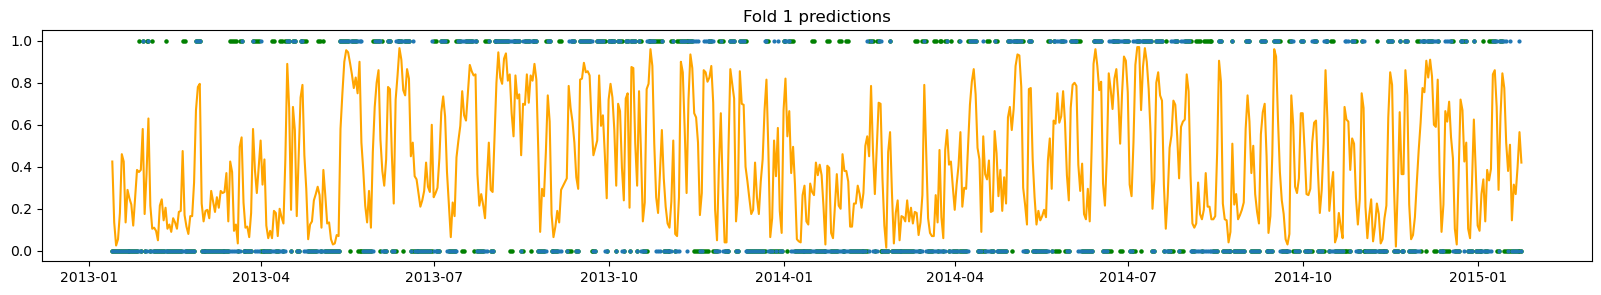

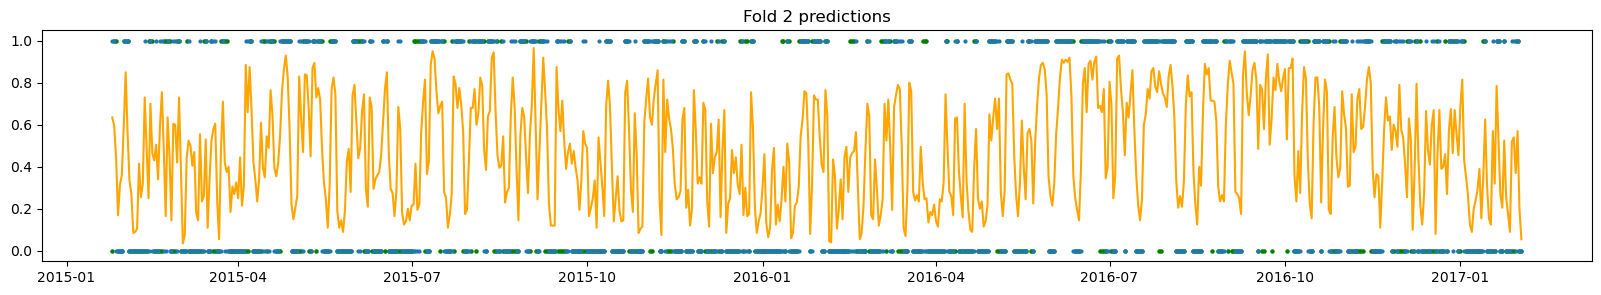

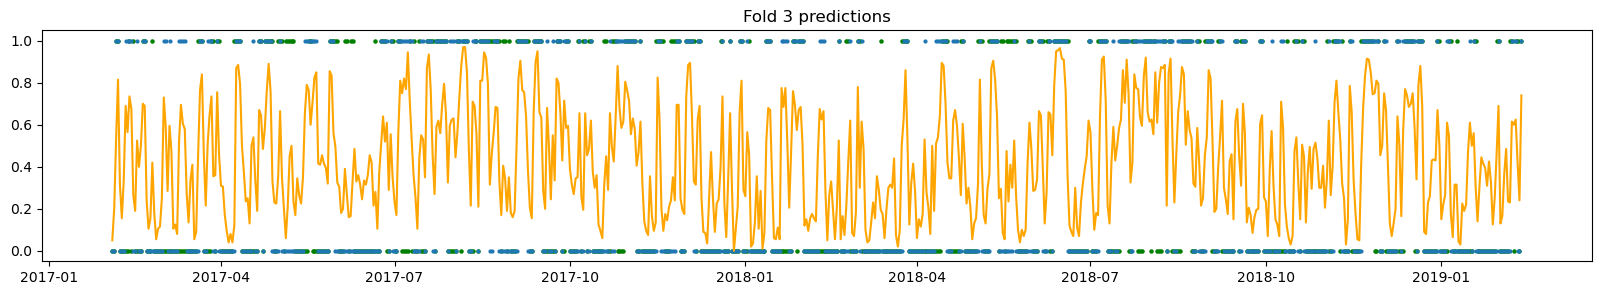

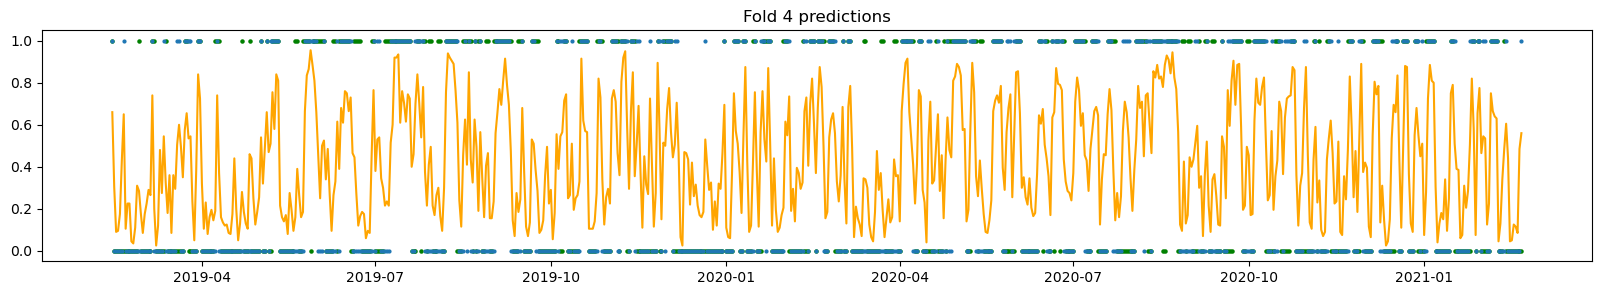

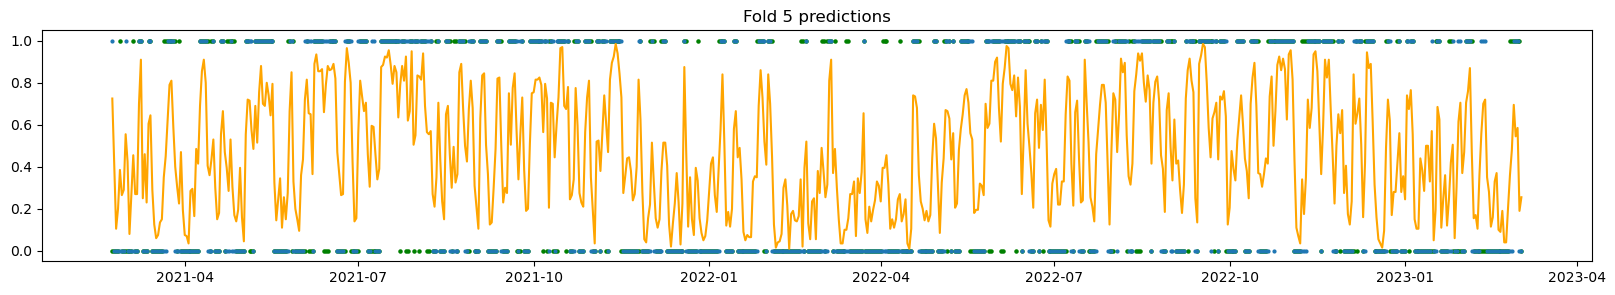

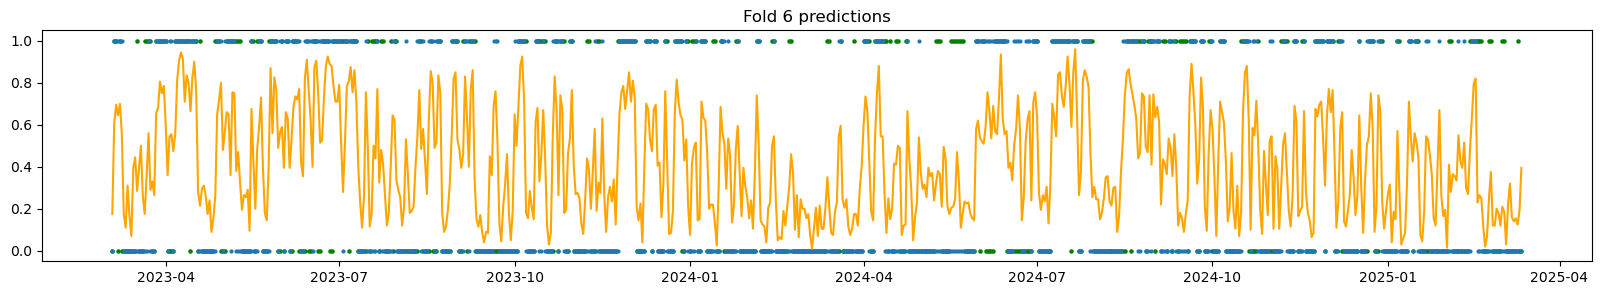

In [241]:
for i in range(len(fold_predictions)):
    plt.figure(figsize=(20,3))
    plt.scatter(fold_times[i],fold_actual[i], s=5, color = "green")
    plt.scatter(fold_times[i],fold_predictions[i],s =4)
    plt.plot(fold_times[i],fold_probs[i], color="orange")
    plt.title(f"Fold {i+1} predictions")



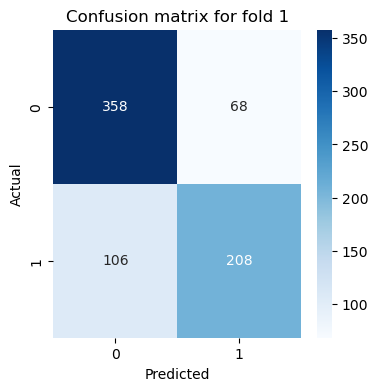

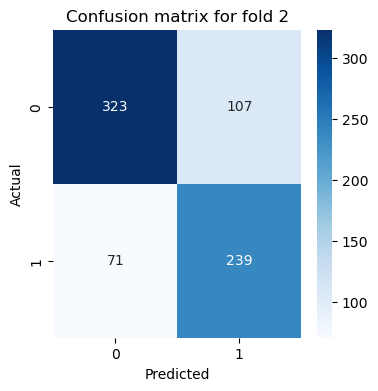

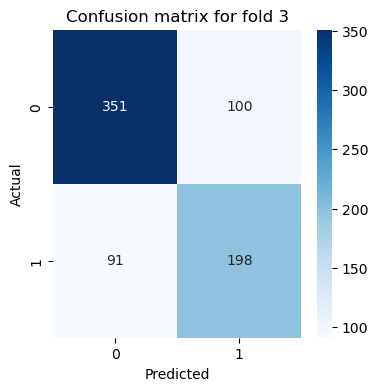

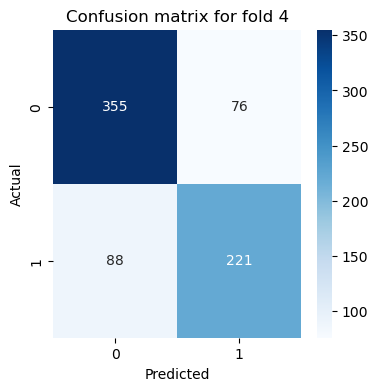

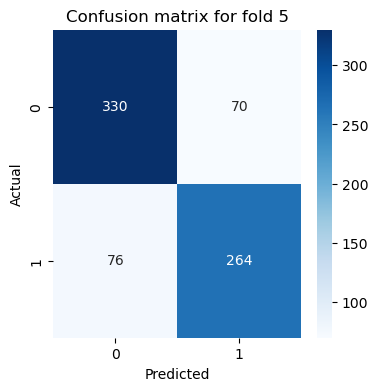

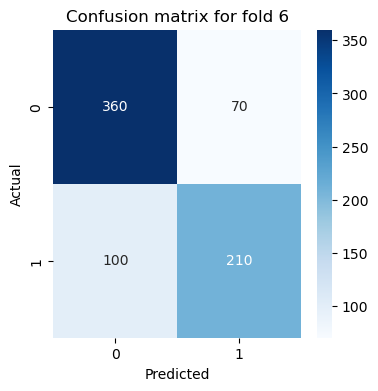

In [221]:
for i, graph in enumerate(cm, start =1):
    plt.figure(figsize = (4,4))
    sns.heatmap(graph, annot =True,fmt = 'd',cmap='Blues')
    plt.title(f"Confusion matrix for fold {i}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

Text(95.72222222222221, 0.5, 'Actual')

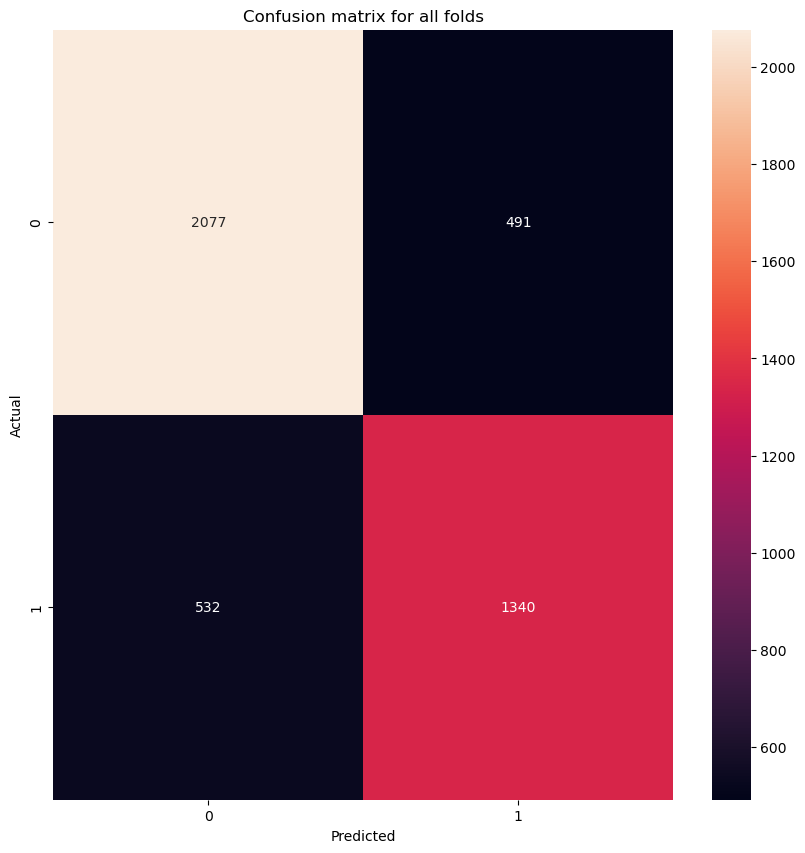

In [222]:
comb_cm = sum(cm)
plt.figure(figsize = (10,10))
sns.heatmap(comb_cm, annot = True, fmt = 'd') 
plt.title(f"Confusion matrix for all folds")
plt.xlabel("Predicted")
plt.ylabel("Actual")               

In [223]:
importance = classifer_tss.feature_importances_
features = X.columns
feat_import = pd.DataFrame({"Features": X.columns, "Importance": importance}).sort_values(by = "Importance",ascending = False)

In [224]:
feat_import

,Features,Importance
10,pre1,0.157899
4,hum,0.127325
3,air_temp,0.105208
7,pre,0.085532
11,pre2,0.072600
8,huml1,0.064516
6,wind_gust,0.063917
5,wind_speed,0.062259
12,air_temp1,0.060734
13,air_temp2,0.051152


In [225]:
for i in range(len(cm)):
    TN, FP, FN, TP = cm[i].ravel()
    print(f"Fold {i+1}")
    print("TN: ", TN),
    print("FP: ", FP),
    print("FN: ", FN),
    print("TP: ", TP)
    print("Accuracy: ", (TP+TN)/(TP+TN+FN+FP))
    print("Precision: ", (TP)/ (TP + FP))
    print("Recall: ", (TP)/(TP +FN))

    print(" ")

Fold 1
TN:  358
FP:  68
FN:  106
TP:  208
Accuracy:  0.7648648648648648
Precision:  0.7536231884057971
Recall:  0.6624203821656051
 
Fold 2
TN:  323
FP:  107
FN:  71
TP:  239
Accuracy:  0.7594594594594595
Precision:  0.6907514450867052
Recall:  0.7709677419354839
 
Fold 3
TN:  351
FP:  100
FN:  91
TP:  198
Accuracy:  0.7418918918918919
Precision:  0.6644295302013423
Recall:  0.6851211072664359
 
Fold 4
TN:  355
FP:  76
FN:  88
TP:  221
Accuracy:  0.7783783783783784
Precision:  0.7441077441077442
Recall:  0.7152103559870551
 
Fold 5
TN:  330
FP:  70
FN:  76
TP:  264
Accuracy:  0.8027027027027027
Precision:  0.7904191616766467
Recall:  0.7764705882352941
 
Fold 6
TN:  360
FP:  70
FN:  100
TP:  210
Accuracy:  0.7702702702702703
Precision:  0.75
Recall:  0.6774193548387096
 


In [226]:
TN, FP, FN, TP = comb_cm.ravel()
print(f"Analysis of all ")
print("TN: ", TN),
print("FP: ", FP),
print("FN: ", FN),
print("TP: ", TP)
print("Accuracy: ", (TP+TN)/(TP+TN+FN+FP))
print("Precision: ", (TP)/ (TP + FP))
print("Recall: ", (TP)/(TP +FN))

print(" ")

Analysis of all 
TN:  2077
FP:  491
FN:  532
TP:  1340
Accuracy:  0.7695945945945946
Precision:  0.7318405243036592
Recall:  0.7158119658119658
 


In [231]:
fold_probs

[array([[0.655, 0.345],
        [0.86 , 0.14 ],
        [0.93 , 0.07 ],
        ...,
        [0.565, 0.435],
        [0.46 , 0.54 ],
        [0.49 , 0.51 ]]),
 array([[0.51 , 0.49 ],
        [0.385, 0.615],
        [0.56 , 0.44 ],
        ...,
        [0.495, 0.505],
        [0.73 , 0.27 ],
        [0.92 , 0.08 ]]),
 array([[0.97 , 0.03 ],
        [0.785, 0.215],
        [0.345, 0.655],
        ...,
        [0.58 , 0.42 ],
        [0.76 , 0.24 ],
        [0.27 , 0.73 ]]),
 array([[0.275, 0.725],
        [0.63 , 0.37 ],
        [0.945, 0.055],
        ...,
        [0.9  , 0.1  ],
        [0.51 , 0.49 ],
        [0.485, 0.515]]),
 array([[0.31 , 0.69 ],
        [0.63 , 0.37 ],
        [0.905, 0.095],
        ...,
        [0.41 , 0.59 ],
        [0.725, 0.275],
        [0.67 , 0.33 ]]),
 array([[0.775, 0.225],
        [0.405, 0.595],
        [0.33 , 0.67 ],
        ...,
        [0.875, 0.125],
        [0.845, 0.155],
        [0.76 , 0.24 ]])]